In [3]:
#! pip uninstall torch torchvision torchaudio -y
! pip3 install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128

Looking in indexes: https://download.pytorch.org/whl/cu128
  Using cached https://download.pytorch.org/whl/cu128/torch-2.7.1%2Bcu128-cp311-cp311-win_amd64.whl.metadata (27 kB)
  Using cached https://download.pytorch.org/whl/cu128/torchvision-0.22.1%2Bcu128-cp311-cp311-win_amd64.whl.metadata (6.3 kB)
  Using cached https://download.pytorch.org/whl/cu128/torchaudio-2.7.1%2Bcu128-cp311-cp311-win_amd64.whl.metadata (6.8 kB)
  Using cached https://download.pytorch.org/whl/filelock-3.13.1-py3-none-any.whl.metadata (2.8 kB)
  Using cached https://download.pytorch.org/whl/sympy-1.13.3-py3-none-any.whl.metadata (12 kB)
  Using cached https://download.pytorch.org/whl/networkx-3.3-py3-none-any.whl.metadata (5.1 kB)
  Using cached https://download.pytorch.org/whl/Jinja2-3.1.4-py3-none-any.whl.metadata (2.6 kB)
  Using cached https://download.pytorch.org/whl/fsspec-2024.6.1-py3-none-any.whl.metadata (11 kB)
  Using cached https://download.pytorch.org/whl/numpy-2.1.2-cp311-cp311-win_amd64.whl.metada


[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import torch
print(torch.cuda.is_available())  # ¿True?
print(torch.version.cuda)         # ¿"11.8", "12.1", etc?
print(torch.cuda.get_device_name(0))  # ¿Detecta tu GPU?


True
12.8
NVIDIA GeForce RTX 4070 SUPER


In [5]:
! pip install opencv-python pandas

  Using cached opencv_python-4.11.0.86-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached pandas-2.2.3-cp311-cp311-win_amd64.whl.metadata (19 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
Using cached opencv_python-4.11.0.86-cp37-abi3-win_amd64.whl (39.5 MB)
Using cached pandas-2.2.3-cp311-cp311-win_amd64.whl (11.6 MB)
Using cached pytz-2025.2-py2.py3-none-any.whl (509 kB)
Using cached tzdata-2025.2-py2.py3-none-any.whl (347 kB)



[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
import os
import cv2
import pandas as pd

ruta_base = "E:/Users/Documents/Trabajo/Cedulas/imagenes_cedula_peq"  # Cambia esto por la ruta a tu carpeta raíz
data = []  # Lista para guardar (ruta, etiqueta)

for carpeta_actual, subcarpetas, archivos in os.walk(ruta_base):
    for archivo in archivos:
        if archivo.lower().endswith((".jpg", ".png")):
            ruta_completa = os.path.join(carpeta_actual, archivo)
            label = os.path.basename(carpeta_actual)
            data.append({"Path": ruta_completa, "Label": label})

# Crear el DataFrame
df = pd.DataFrame(data)
print(df.head())

                                                Path            Label
0  E:/Users/Documents/Trabajo/Cedulas/imagenes_ce...  Cedula_Amarilla
1  E:/Users/Documents/Trabajo/Cedulas/imagenes_ce...  Cedula_Amarilla
2  E:/Users/Documents/Trabajo/Cedulas/imagenes_ce...  Cedula_Amarilla
3  E:/Users/Documents/Trabajo/Cedulas/imagenes_ce...  Cedula_Amarilla
4  E:/Users/Documents/Trabajo/Cedulas/imagenes_ce...  Cedula_Amarilla


C:\Users\jeff_\AppData\Local\Temp\ipykernel_39032\3432273608.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Label', y='Cantidad', data=conteo, palette='viridis')


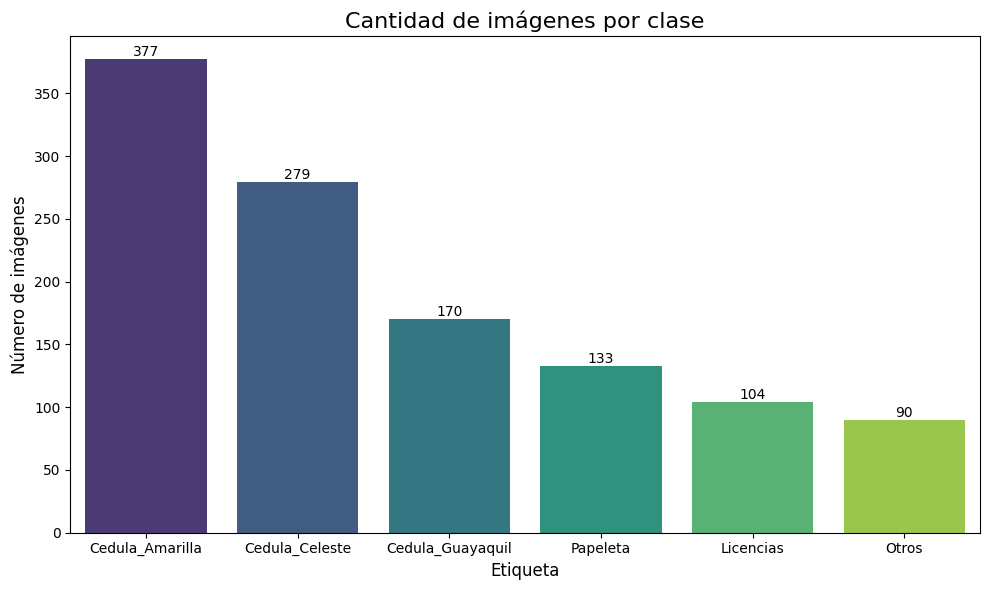

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# Conteo de imágenes por clase
conteo = df['Label'].value_counts().reset_index()
conteo.columns = ['Label', 'Cantidad']

# Crear figura
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Label', y='Cantidad', data=conteo, palette='viridis')

# Mostrar los valores encima de cada barra
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}',               # texto
                (p.get_x() + p.get_width() / 2., height),  # posición
                ha='center', va='bottom', fontsize=10)

# Personalización del gráfico
plt.title('Cantidad de imágenes por clase', fontsize=16)
plt.xlabel('Etiqueta', fontsize=12)
plt.ylabel('Número de imágenes', fontsize=12)
plt.tight_layout()
plt.show()


In [ ]:
#%matplotlib inline
#
#from ultralytics import YOLO
#import cv2
#import matplotlib.pyplot as plt
#import random
##from paddleocr import PaddleOCR
#import numpy as np
##import easyocr
#from PIL import Image
##ocr = PaddleOCR(use_angle_cls=True, lang='es')
#fig,axes=plt.subplots(10,4, figsize=(40, 60))
#axes = axes.flatten()
#fig_2,axes_2=plt.subplots(10,4, figsize=(40, 60))
#axes_2 = axes_2.flatten()
#random.seed(42)  # Fijar la semilla para reproducibilidad
#imges_muestra = random.sample(images,40)  # Selecciona una imagen aleatoria de la lista
## Cargar el modelo YOLOv5 o YOLOv8 entrenado
#model = YOLO("E:/Users/Documents/Trabajo/Cedulas/best copy.pt")
## Leer la imagen
#
## Realizar la inferencia
#conf_threshold = 0.7  # Ajusta este valor a tu preferencia
#roi_array=[]
#for i, image in enumerate(imges_muestra):
#    results = model(image, device='cpu')  # o 'cpu' si no hay GPU
#
#    # Filtrar cajas por confianza
#    filtered_boxes = results[0].boxes  # Objeto Boxes de Ultralytics
#    #print(filtered_boxes)
#    mask = filtered_boxes.conf > conf_threshold
#    #print("###########",filtered_boxes.xyxy[0].tolist())
#
#    # Si hay detecciones que pasan el filtro
#    if mask.any():
#        filtered_boxes = filtered_boxes[mask]
#        results[0].boxes = filtered_boxes  # Sobrescribimos con solo las que pasan el umbral
#
#        # Dibujar y mostrar
#        annotated_image = results[0].plot()
#    else:
#        # Si no hay detecciones válidas, mostrar la imagen original
#        annotated_image = image.copy()
#
#    annotated_image_rgb = cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB)
#    axes[i].imshow(annotated_image_rgb)
#    axes[i].axis('off')
#    box=[int(cd) for cd in filtered_boxes.xyxy.tolist()[0]]
#    xmin,ymin,xmax,ymax=box
#    roi_orin = image[ymin:ymax, xmin:xmax]
#    roi = cv2.cvtColor(roi_orin, cv2.COLOR_BGR2GRAY)
#    roi = Image.fromarray(roi_orin)
#    # Convertir a RGB (Tesseract espera imágenes RGB, no BGR)
#    axes_2[i].imshow(roi)
#    roi_array.append(roi)
#
#
#

In [ ]:

import torchvision as tv
from PIL import Image
import torch.nn as nn
import torch
from torchvision import models

transform = tv.transforms.Compose([
            tv.transforms.Resize((224, 224)),
            tv.transforms.ToTensor(),
            tv.transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
        ])

class MobileNetV2Custom(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = models.mobilenet_v2(weights="IMAGENET1K_V2")
        # Congelar capas convolucionales
        for param in self.model.features.parameters():
            param.requires_grad = False

    def forward(self, x):
        # Extraer características
        features = self.model.features(x)
        features = nn.functional.adaptive_avg_pool2d(features, (1, 1))
        features = torch.flatten(features, 1)
        return features

    def extract_features(self, image_tensor: torch.Tensor) -> torch.Tensor:
        """Método explícito para inferencia"""
        self.eval()
        with torch.no_grad():
            return self(image_tensor)
